# Distance Metric Analysis: Hamming vs Edit Distance for CRISPR Spacer Detection

## Overview

This notebook quantifies how distance metric choice affects background (non-planned) alignment rates using simulated CRISPR spacer data with ground truth; historically these non-planned alignments were called non-planned matches.
- **Hamming Distance** (≤N): Substitutions only, no indels allowed
- **Edit Distance** (≤N): Substitutions + indels allowed

We use the `compare-results` command which implements:
- **Coordinate tolerance matching** (5bp default) to handle slight boundary differences (e.g., placing a gap instead of a substitution in the terminal region of an alignment)
- **Verification**: All reported alignments (including those not in the ground truth) are verified by extracting the reference region and aligning to the reported spacer sequence
- **Classification into three categories**:
  - `positive_in_plan`: Matches ground truth (true positives)
  - `positive_not_in_plan`: Valid alignment NOT in ground truth (background/chance matches, or real matches when no GT exists)
  - `invalid_alignment`: **True False Positives** - failed verification (exceeds distance threshold)
- **Augmented metrics**: For simulated runs, adjusts metrics to include verified non-planned alignments as true positives

## Important Terminology:

**why are there no "False Positives" in this analysis?**
We find this term misleading, and define some custom metrics:
- **Invalid alignments** = True false positives (alignments that fail validation - the distance measured is larger than the accepted threshold). Note, some tools don't really let us control setting a threshold, so some level of these is expected.
- **Positives not in plan** ≠ False positives! These are:
  - Valid alignments that arise by chance (background matches)
  - Real biological matches (when there is no ground truth, e.g. real meta/genomes vs real spacers)
  - We mostly **ignore invalid alignments** in these plots and focus on background (non-planned) alignment rates. Main reason is that not all tools allow strict control over distance thresholds, so invalid alignments may be present due to tool's varying control over reporting setting - for example, with blastn, we can't hard-set a max edit/hamming distance, the closest we can do is set a min percent identity and min query (spacer) coverage, which allow a range of distances to be reported, and this range may exceed our desired threshold in order to capture all valid matches (for example, a 85% identity, over at least 80% of the spacer, will allow for 3 distance for a spacer of length 20 (20 * 0.15 ), but will allow more for a spacer of length 30 (30 * 0.15 = 4.5) [[[note that the length also matters - the %id is out of the aligned region, hence the qcoverage setting being so high]]]). In this example, if we use the code here and in compare_results.py to validate the alignments at 3 distance, those blastn alignments with distance 4 or 5 will be marked as invalid alignments, but that doesn't mean blastn did something wrong.
- **"*_Augemented"** = performance metrics that include all verified non-planned alignments (within allowed distance) as true positives.


**Metrics:**
- **TP_planned**: Planned spacers correctly identified
- **GT_planned**: Simulated ground truth (where/how we inserted spacers)
- **All_TP**: TP_planned + verified non-planned
- **GT_augmented**: GT_planned + verified non-planned
- **Invalid alignments**: Alignments that failed verification (true FPs)

**Performance Metrics:**
- **Precision (planned)**: TP_planned / (TP_planned + all non-TP)
- **Recall (planned)**: TP_planned / GT_planned
- **Precision (augmented)**: All_TP / (All_TP + invalid_alignments)
- **Recall (augmented)**: All_TP / GT_augmented
- **Non-planned Rate**: `positives_not_in_plan / all_true_positives × 100` - not useful! this is dependent on how many planned insertions we made, and we control that value.
- **Invalid Rate**: `invalid_alignments / (all_alignments) × 100`  - "True" false positive rate, **however**, in many tools we can't strictly control the reporting to be exactly within our desired metric and value - hence this rate doesn't really indicate a tool is "wrong" or "bad", just that we couldn't strictly control it at command exec time.  
- **Background Frequency**: Expected number of non-planned matches, per a given search size: either for every n spacers searched in m contigs, or per n spacer-bp searched in m contig-bp (i.e. total length for each spacer searched, combined). This is a more useful metric, as it is independent of how many planned insertions we made). Apart from the simulations variables, this value is dependent on the distance metric used, the search space size, and threshold allowed.  

**Coordinate Tolerance Matching**: 
   - up to 5bp tolerance for alignments region -the slight boundary differences reduce the "double-counting" of e.g. a hit indel vs substitution placement on terminal ends.
   - Example: tool reports 5000-5036 (with 1 insertion) vs ground truth 5001-5036 (with 1 mismatch) → the hit with insertion is: verified (within the edit/hamming of up to 1 for the region in front of the spacer), and then counted as a 1 planned ground truth entry.   


**Reminder**: these analyses use a tool-independent aggreaget `all_tools_combined`, which merges unique alignments from all tools (allowing some coordinate tolerance for boundary differences).and validates each alignment. This avoids double-counting and provides accurate background alignment rates.
This might decrease the total count of hamming compared to edit - as traditionally, hamming is expected to be of two strings of equal length. By allowing this small terminal ambiguity we kind of break that assumption. In the backend, in the validation step for these strings for hamming up to n, we pad the shorter sequence with `@` (a non IUPAC char, nothing aligns to it) (one time padding the aligned region from the right and one time from the left, then selecting the padded version with lowest hamming value), to make the lengths equal. In reality, a pure hamming distance based tool might still report these variations, if they are within the allowed threshold. For an edit/indel-allowing tool, non-equal lengths are a non-issue - and they may sometime "miss" (not report) the truncated version of the aligned region, if they can open a small gap that would allow a perfect match within the allowed edit distance. In this case, that reported alignment would be counted as a planned match if it overlaps the ground truth region within the coordinate tolerance, and the edit distance is within the allowed threshold. 
For example:
```bash
(benchy) [uneri@ln008 spacer_bench]$ grep "1c47e31b_spacer_10034" results/simulated/ns_100000_nc_10000/raw_outputs/*tsv |  grep "1c47e31b_contig_1828"
#                                                                            qaccver               saccver            nident length mismatch   qlen  gapopen qstart    qend   sstart   send    evalue      bitscore
results/simulated/ns_100000_nc_10000/raw_outputs/blastn_output.tsv:1c47e31b_spacer_10034        1c47e31b_contig_1828    34      34      0       35      0       1       34      5036    5003    5.27e-11       67.9

#                                                                                 query         ,target,              nident,alnlen,mismatch,qlen  ,gapopen, qstart,  qend,   tstart,  tend,  evalue,         bits
results/simulated/ns_100000_nc_10000/raw_outputs/mmseqs_output.tsv:1c47e31b_spacer_10034        1c47e31b_contig_1828    34      35      1       35      0       35      1       5002    5036    1.550E-10      60

#                                                                       pat_id          text_id               cost    strand    start   end       match_region                           cigar
results/simulated/ns_100000_nc_10000/raw_outputs/sassy.tsv:1c47e31b_spacer_10034        1c47e31b_contig_1828    1       -       5000    5036    AGTCTGGGCAGATGTGTCGACCGTTGTCTGACCGTG    34=1I1=


(benchy) [uneri@ln008 spacer_bench]$ grep "1c47e31b_spacer_10034" results/simulated/ns_100000_nc_10000/simulated_data/planned_ground_truth.tsv  | grep "1c47e31b_contig_1828"
# spacer_id              contig_id              start   end     strand  mismatches
1c47e31b_spacer_10034   1c47e31b_contig_1828    5001    5036    true    1
```


## *Update*: Tool-Independent Metrics

Previously (preprint versions) we handled aggregating tool results in these notebooks. Now the `compare-results` command creates a "fake" tool entry called `all_tools_combined` which is the union of all tool results -- contains all unique alignments (or regions) across tools using the existing coordinate tolerance and validation logic. This notebook now uses that tool-independent aggregate, which eliminates some issues. Notably this fixes a double-counting issue regarding the legacy "validated non-planned" matches.

**Background Frequency Metrics** (independent of planned insertion count):
We focus on background match **frequency** given the search space, not compared to the planned ground truth (planned occurrences) which we control. As long as the planned spacers don't occupy a majority of the contig sequence (<1%), the planned rate is completely set by us (`spacer_bencher simulate --spacer-insertions nnn`) and independent from the non-planned rate.

**NEW in V2**: Uses the efficient multi-metric workflow:
1. Runs `compare-results --multi-metric` ONCE per dataset (generates all 3 metrics)
2. Loads `multi_metric_distances.parquet` file
3. Filters by threshold in memory for analysis


In [1]:
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

os.chdir('/clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/')

import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import subprocess
from pathlib import Path
import glob

# Configuration
MAX_MISMATCHES = 5  # Maximum threshold for validation
THRESHOLDS = list(range(0, MAX_MISMATCHES + 1))  # Analyze all thresholds 0-5

# Threshold labels with ≤ notation
THRESHOLD_LABELS = [f"≤{t}" for t in THRESHOLDS]

print(f"Analyzing thresholds: {', '.join(THRESHOLD_LABELS)}")
print(f"Configuration: Max mismatches = {MAX_MISMATCHES}")

Analyzing thresholds: ≤0, ≤1, ≤2, ≤3, ≤4, ≤5
Configuration: Max mismatches = 5


In [2]:
def ensure_multi_metric_file(sim_dir: Path, force_regenerate: bool = False) -> Path:
    """
    Ensure the multi-metric parquet file exists for a simulation.
    
    If the file doesn't exist or force_regenerate is True, runs compare-results 
    with --multi-metric to generate it. This runs the validation ONCE for all metrics.
    
    Returns the path to the multi_metric_distances.parquet file.
    """
    mm_file = sim_dir / f"multi_metric_distances.parquet"
    
    if mm_file.exists() and not force_regenerate:
        print(f"✓ Multi-metric file exists: {mm_file.name}")
        return mm_file
    
    print(f"Generating multi-metric file for {sim_dir.name}...")
    
    # Create logs directory
    logs_dir = sim_dir / "logs"
    logs_dir.mkdir(exist_ok=True)
    
    # Build command
    cmd = [
        "pixi", "run", "compare-results",
        str(sim_dir),
        "-m", str(MAX_MISMATCHES),
        "--multi-metric",
        "--multi-metric-output", str(mm_file),
        "--logfile", str(logs_dir / f"compare_results_mm{MAX_MISMATCHES}.log")
    ]
    
    # Run the command
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"ERROR: compare-results failed for {sim_dir.name}")
        print(result.stderr)
        raise RuntimeError(f"compare-results failed with code {result.returncode}")
    
    if not mm_file.exists():
        raise FileNotFoundError(f"Expected {mm_file} was not created")
    
    print(f"✓ Generated: {mm_file.name}")
    return mm_file


def calculate_metrics_from_parquet(
    parquet_path: Path,
    threshold: int,
    metric: str = "hamming"
) -> dict:
    """
    Load multi-metric parquet and calculate metrics for a specific threshold.
    
    This filters the parquet file by threshold instead of re-running validation,
    which is much more efficient.
    
    Args:
        parquet_path: Path to multi_metric_distances.parquet
        threshold: Distance threshold to filter by
        metric: Which distance metric to use ('hamming', 'edit', or 'gap_affine')
    
    Returns:
        Dictionary with metrics:
        - n_tp: True positives (positive_in_plan)
        - n_non_planned: Non-planned alignments (positive_not_in_plan)
        - n_invalid: Invalid alignments
        - non_planned_rate: Percentage of non-planned among all positives
        - invalid_rate: Percentage of invalid among all alignments
    """
    # Load parquet
    df = pl.read_parquet(parquet_path)
    
    # Get the appropriate distance column
    distance_col = f"distance_{metric}"
    if distance_col not in df.columns:
        raise ValueError(f"Distance metric '{metric}' not found in parquet. Available: {df.columns}")
    
    # Filter to all_tools_combined and threshold
    filtered = df.filter(
        (pl.col("tools").list.contains("all_tools_combined")) &
        (pl.col(distance_col) <= threshold)
    )
    
    # Count by classification
    counts = filtered.group_by("classification").agg(pl.len().alias("count"))
    counts_dict = dict(zip(counts["classification"].to_list(), counts["count"].to_list()))
    
    n_tp = counts_dict.get("positive_in_plan", 0)
    n_non_planned = counts_dict.get("positive_not_in_plan", 0)
    n_invalid = counts_dict.get("invalid_alignment", 0)
    
    total_positives = n_tp + n_non_planned
    total_alignments = total_positives + n_invalid
    
    non_planned_rate = (n_non_planned / total_positives * 100) if total_positives > 0 else 0.0
    invalid_rate = (n_invalid / total_alignments * 100) if total_alignments > 0 else 0.0
    
    return {
        "n_tp": n_tp,
        "n_non_planned": n_non_planned,
        "n_invalid": n_invalid,
        "non_planned_rate": non_planned_rate,
        "invalid_rate": invalid_rate
    }


def analyze_simulation_multi_metric(
    sim_dir: Path,
    metrics: list[str] = ["hamming", "edit"],
    force_regenerate: bool = False
) -> dict:
    """
    Analyze a simulation for multiple distance metrics across all thresholds.
    
    Uses the NEW efficient workflow:
    1. Run compare-results ONCE with --multi-metric
    2. Load parquet file ONCE
    3. Filter by threshold in memory for each analysis
    
    Args:
        sim_dir: Simulation directory path
        metrics: List of metrics to analyze (e.g., ['hamming', 'edit', 'gap_affine'])
        force_regenerate: Force regeneration of multi-metric file
    
    Returns:
        Dictionary with results per metric per threshold
    """
    # Ensure multi-metric file exists
    mm_file = ensure_multi_metric_file(sim_dir, force_regenerate=force_regenerate)
    
    results = {metric: {} for metric in metrics}
    
    # For each metric, calculate metrics at each threshold
    for metric in metrics:
        for threshold in THRESHOLDS:
            metrics_dict = calculate_metrics_from_parquet(mm_file, threshold, metric)
            results[metric][threshold] = metrics_dict
    
    return results

In [3]:
# Find all simulated datasets
sim_dirs = sorted(glob.glob("results/simulated/ns_*_nc_*"))
sim_dirs = [Path(d) for d in sim_dirs if Path(d).is_dir()]

# Separate regular simulations from semi-synthetic
regular_sims = [d for d in sim_dirs if "real_baseline" not in d.name and "HIGH_INSERTION_RATE" not in d.name  and "ns_500000_nc_100000" not in d.name and "ns_100_nc_5000" not in d.name] ### Remove the debug and partial sims
semisynthetic_sims = [d for d in sim_dirs if "real_baseline" in d.name]

print(f"Found {len(regular_sims)} regular simulations")
print(f"Found {len(semisynthetic_sims)} semi-synthetic simulations")
print(f"\nSemi-synthetic datasets: {[d.name for d in semisynthetic_sims]}")


Found 4 regular simulations
Found 1 semi-synthetic simulations

Semi-synthetic datasets: ['ns_3826979_nc_421431_real_baseline']


In [4]:
# Analyze all simulations for Hamming and Edit distance
all_results = {}

print("Analyzing simulations (using multi-metric workflow)...\n")

for sim_dir in regular_sims:
    print(f"Processing {sim_dir.name}...")
    try:
        results = analyze_simulation_multi_metric(
            sim_dir,
            metrics=["hamming", "edit"],
            force_regenerate=False  # Set to True to regenerate all files
        )
        all_results[sim_dir.name] = results
        print(f"  ✓ Complete\n")
    except Exception as e:
        print(f"  ✗ ERROR: {e}\n")
        continue

print(f"\nSuccessfully analyzed {len(all_results)} / {len(regular_sims)} simulations")

Analyzing simulations (using multi-metric workflow)...

Processing ns_100000_nc_10000...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete

Processing ns_100000_nc_20000...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete

Processing ns_50000_nc_5000...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete

Processing ns_75000_nc_5000...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete


Successfully analyzed 4 / 4 simulations


## Frequency Comparison: Hamming vs Edit Distance

**Key metrics** (independent of planned insertions):
1. **Absolute non-planned count**: Total number of alignments not in the plan
2. **Per spacer per Gbp target**: `non-planned / (n_spacers × contig_bp / 1e9)` -- expected background hits per query spacer when searching against 1 Gbp of target sequence
3. **Per Gbp² search space**: `non-planned / (spacer_bp × contig_bp / 1e18)` -- fully length-normalized rate accounting for query lengths, target lengths, and query count

- Are the normalized metrics consistent across different search space sizes?
- How does the difference scale with threshold?

####  individual simulations plots 

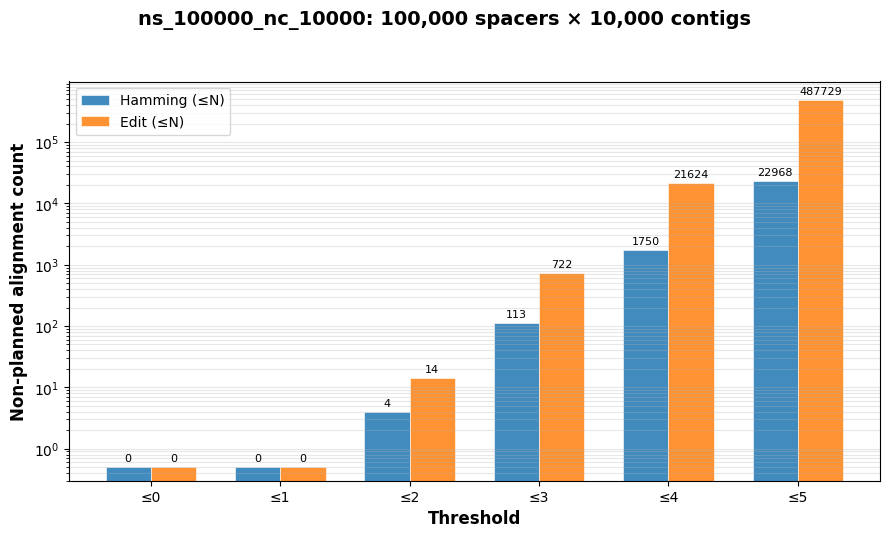

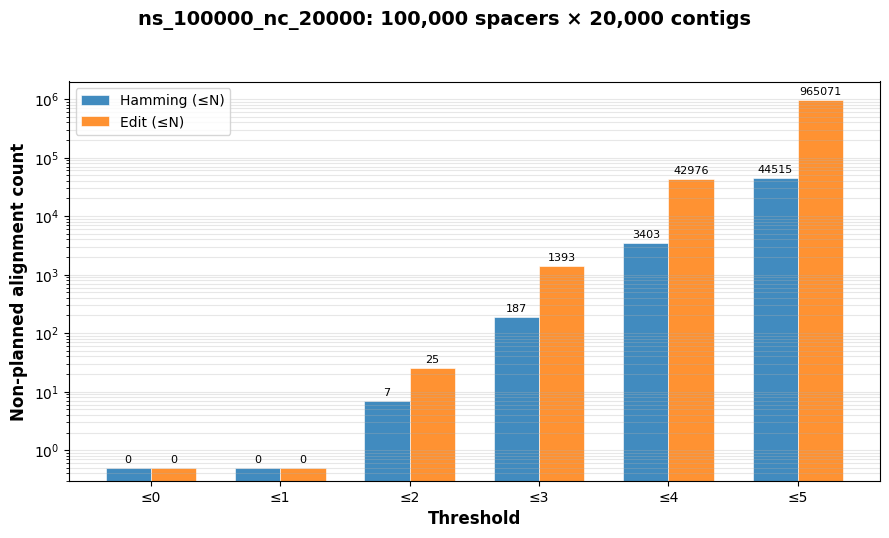

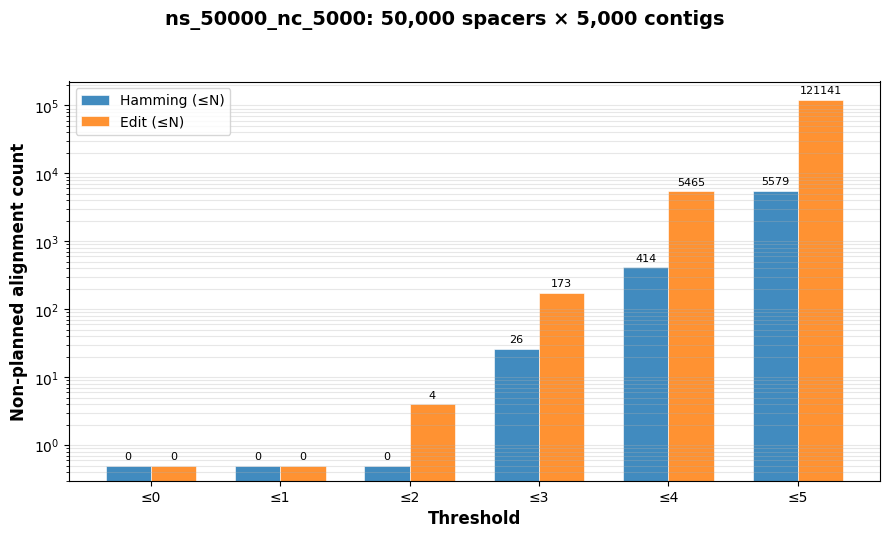

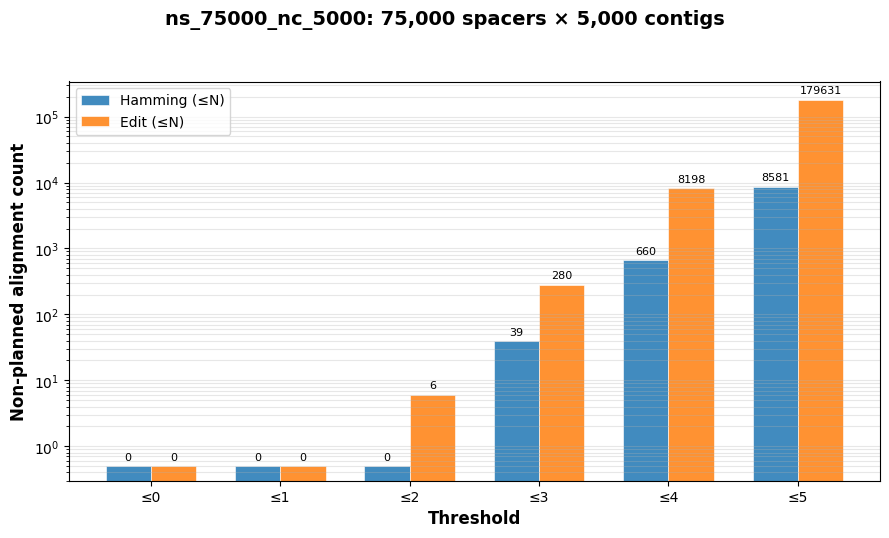

Saved per-simulation figures to draft/supp/supp_figures (n=4)


In [7]:
# Per-simulation figures: grouped bar chart (Hamming vs Edit)
n_sims = len(all_results)
Path("draft/supp/figures").mkdir(parents=True, exist_ok=True)

bar_width = 0.35

for sim_name, results in all_results.items():
    parts = sim_name.split('_')
    try:
        n_spacers = int(parts[1])
        n_contigs = int(parts[3])
    except (IndexError, ValueError):
        print(f"Skipping {sim_name}: cannot parse counts")
        continue

    hamming_counts = [results["hamming"][t]["n_non_planned"] for t in THRESHOLDS]
    edit_counts = [results["edit"][t]["n_non_planned"] for t in THRESHOLDS]

    fig, ax = plt.subplots(figsize=(9, 5.5))

    x = np.arange(len(THRESHOLDS))
    # Replace 0 with a small value for log-scale display, but track which are truly zero
    h_plot = np.array([max(v, 0.5) for v in hamming_counts], dtype=float)
    e_plot = np.array([max(v, 0.5) for v in edit_counts], dtype=float)

    bars_h = ax.bar(x - bar_width/2, h_plot, bar_width, label='Hamming (≤N)',
                    color='#1f77b4', alpha=0.85, edgecolor='white', linewidth=0.5)
    bars_e = ax.bar(x + bar_width/2, e_plot, bar_width, label='Edit (≤N)',
                    color='#ff7f0e', alpha=0.85, edgecolor='white', linewidth=0.5)

    # Annotate bars with actual counts
    for i, (h, e) in enumerate(zip(hamming_counts, edit_counts)):
        ax.text(x[i] - bar_width/2, h_plot[i] * 1.15, str(h), ha='center', va='bottom', fontsize=8)
        ax.text(x[i] + bar_width/2, e_plot[i] * 1.15, str(e), ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax.set_ylabel('Non-planned alignment count', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'≤{t}' for t in THRESHOLDS])
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.3)
    ax.grid(True, alpha=0.3, axis='y', which='both')
    ax.legend(fontsize=10)

    fig.suptitle(f"{sim_name}: {n_spacers:,} spacers × {n_contigs:,} contigs",
                 fontsize=14, fontweight='bold', y=0.97)
    plt.tight_layout(rect=[0, 0, 1, 0.93])

    # map to files for consistency:
    file_name_map = {
        "ns_50000_nc_5000": "FigureS9A",
        "ns_75000_nc_5000": "FigureS9B",
        "ns_100000_nc_10000": "FigureS9C",
        "ns_100000_nc_20000": "FigureS9D"
    }
    # draft/supp/supp_figures
    outfile = Path("draft/supp/supp_figures/") / f"{file_name_map.get(sim_name, 'FigureS9')}_{sim_name}_background_counts_foldchange.svg"
    fig.savefig(outfile, bbox_inches='tight')
    plt.show()

print(f"Saved per-simulation figures to draft/supp/supp_figures (n={n_sims})")

Calculating aggregated metrics across all simulations...



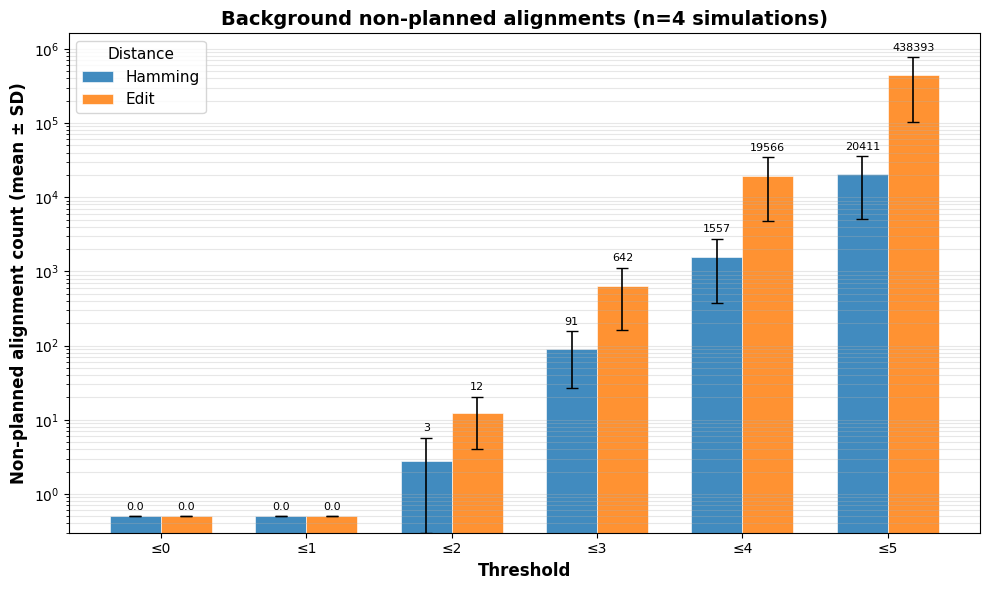


BACKGROUND ALIGNMENT SUMMARY (n=4 simulations)

Threshold ≤0:
  Hamming - Count:      0.0 ±    0.0
  Edit    - Count:      0.0 ±    0.0
  Excess  (Edit−Hamming):      0.0  Fold-change: n/a (Hamming = 0)

Threshold ≤1:
  Hamming - Count:      0.0 ±    0.0
  Edit    - Count:      0.0 ±    0.0
  Excess  (Edit−Hamming):      0.0  Fold-change: n/a (Hamming = 0)

Threshold ≤2:
  Hamming - Count:      2.8 ±    2.9
  Edit    - Count:     12.2 ±    8.3
  Excess  (Edit−Hamming):      9.5  Fold-change: 4.5x

Threshold ≤3:
  Hamming - Count:     91.2 ±   64.5
  Edit    - Count:    642.0 ±  479.9
  Excess  (Edit−Hamming):    550.8  Fold-change: 7.0x

Threshold ≤4:
  Hamming - Count:  1,556.8 ± 1,178.6
  Edit    - Count: 19,565.8 ± 14,835.2
  Excess  (Edit−Hamming): 18,009.0  Fold-change: 12.6x

Threshold ≤5:
  Hamming - Count: 20,410.8 ± 15,390.6
  Edit    - Count: 438,393.0 ± 334,451.2
  Excess  (Edit−Hamming): 417,982.2  Fold-change: 21.5x


In [8]:
# Aggregated comparison: grouped bar chart with mean +/- SD across all simulations
print("Calculating aggregated metrics across all simulations...\n")

# Collect data for each threshold across all simulations
hamming_counts_by_threshold = {t: [] for t in THRESHOLDS}
edit_counts_by_threshold = {t: [] for t in THRESHOLDS}

for sim_name, results in all_results.items():
    parts = sim_name.split('_')
    try:
        n_spacers = int(parts[1])
        n_contigs = int(parts[3])
    except (IndexError, ValueError):
        print(f"Warning: Could not parse {sim_name}, skipping")
        continue

    for t in THRESHOLDS:
        h = results["hamming"][t]
        e = results["edit"][t]
        hamming_counts_by_threshold[t].append(h["n_non_planned"])
        edit_counts_by_threshold[t].append(e["n_non_planned"])

# Means and std
h_count_mean = [np.mean(hamming_counts_by_threshold[t]) for t in THRESHOLDS]
h_count_std = [np.std(hamming_counts_by_threshold[t]) for t in THRESHOLDS]
e_count_mean = [np.mean(edit_counts_by_threshold[t]) for t in THRESHOLDS]
e_count_std = [np.std(edit_counts_by_threshold[t]) for t in THRESHOLDS]

# Grouped bar chart
bar_width = 0.35
x = np.arange(len(THRESHOLDS))

# Floor for log-scale display
h_plot = np.array([max(v, 0.5) for v in h_count_mean])
e_plot = np.array([max(v, 0.5) for v in e_count_mean])

# Clip lower error bars so they don't cross the log floor
h_err_lower = np.array([max(1e-9, min(h_count_std[i], h_plot[i] - 0.3)) for i in range(len(THRESHOLDS))])
e_err_lower = np.array([max(1e-9, min(e_count_std[i], e_plot[i] - 0.3)) for i in range(len(THRESHOLDS))])

fig, ax = plt.subplots(figsize=(10, 6))

bars_h = ax.bar(x - bar_width/2, h_plot, bar_width, yerr=[h_err_lower, h_count_std],
                label='Hamming', color='#1f77b4', alpha=0.85,
                edgecolor='white', linewidth=0.5, capsize=4, error_kw={'linewidth': 1.2})
bars_e = ax.bar(x + bar_width/2, e_plot, bar_width, yerr=[e_err_lower, e_count_std],
                label='Edit', color='#ff7f0e', alpha=0.85,
                edgecolor='white', linewidth=0.5, capsize=4, error_kw={'linewidth': 1.2})

# Annotate bars with mean counts
for i in range(len(THRESHOLDS)):
    h_val = h_count_mean[i]
    e_val = e_count_mean[i]
    h_top = h_plot[i] + h_count_std[i]
    e_top = e_plot[i] + e_count_std[i]
    label_h = f"{h_val:.0f}" if h_val >= 1 else f"{h_val:.1f}"
    label_e = f"{e_val:.0f}" if e_val >= 1 else f"{e_val:.1f}"
    ax.text(x[i] - bar_width/2, h_top * 1.15, label_h, ha='center', va='bottom', fontsize=8)
    ax.text(x[i] + bar_width/2, e_top * 1.15, label_e, ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Threshold', fontweight='bold', fontsize=12)
ax.set_ylabel('Non-planned alignment count (mean ± SD)', fontweight='bold', fontsize=12)
ax.set_title(f'Background non-planned alignments (n={len(all_results)} simulations)',
             fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'≤{t}' for t in THRESHOLDS])
ax.set_yscale('log')
ax.set_ylim(bottom=0.3)
ax.grid(True, alpha=0.3, axis='y', which='both')
ax.legend(fontsize=11, title='Distance', title_fontsize=11)

plt.tight_layout()

# Export SVG for manuscript
fig.savefig('draft/main/main_figures/Figure1_main_search_space_background_normalization.svg', bbox_inches='tight')
fig.savefig('draft/main/main_figures/Figure1_main_search_space_background_normalization.png', bbox_inches='tight',      dpi=500)
plt.show()

# Save summary table for manuscript
summary_rows = []
for i, t in enumerate(THRESHOLDS):
    summary_rows.append({
        "threshold": t,
        "metric": "hamming",
        "count_mean": h_count_mean[i],
        "count_std": h_count_std[i],
    })
    summary_rows.append({
        "threshold": t,
        "metric": "edit",
        "count_mean": e_count_mean[i],
        "count_std": e_count_std[i],
    })
summary_df = pl.DataFrame(summary_rows)
Path("draft/main/figures/tables").mkdir(parents=True, exist_ok=True)
summary_df.write_csv("draft/main/figures/tables/background_alignment_summary.csv")

# Print summary statistics
print(f"\nBACKGROUND ALIGNMENT SUMMARY (n={len(all_results)} simulations)")
for t in THRESHOLDS:
    h_m, h_s = h_count_mean[t], h_count_std[t]
    e_m, e_s = e_count_mean[t], e_count_std[t]
    excess = e_m - h_m
    # Fold-change only when Hamming > 0; otherwise report excess only
    if h_m > 0:
        fc_str = f"  Fold-change: {e_m / h_m:.1f}x"
    else:
        fc_str = "  Fold-change: n/a (Hamming = 0)"
    print(f"\nThreshold ≤{t}:")
    print(f"  Hamming - Count: {h_m:>8,.1f} ± {h_s:>6,.1f}")
    print(f"  Edit    - Count: {e_m:>8,.1f} ± {e_s:>6,.1f}")
    print(f"  Excess  (Edit−Hamming): {excess:>8,.1f}{fc_str}")

## Search Space Analysis: Background Alignment Frequency

The absolute count of non-planned alignments depends on the **search space size** (number of spacers × total contig length). To understand intrinsic background rates, we normalize by search space:

**Three normalization approaches:**
1. **Absolute count**: Raw number of non-planned alignments (dependent on dataset size)
2. **Per spacer per Gbp target**: `non-planned / (n_spacers × contig_bp / 1e9)` -- expected background hits per query spacer when searching against 1 Gbp of target sequence. Decouples query count from target size; directly predictive for new datasets.
3. **Per Gbp² search space**: `non-planned / (spacer_bp × contig_bp / 1e18)` -- fully length-normalized rate. Accounts for query lengths, target lengths, and query count. Best for comparing across datasets with different spacer length distributions.

These metrics help answer:
- Does the background rate scale linearly with search space?
- Are Edit distance background alignments more likely per unit search space?
- Can we predict background alignment counts for new datasets?

In [9]:
from bench.utils.functions import get_seq_stats_pl
all_seq_file_stat_dfs = []
search_space_data = []

# Compute FASTA stats and build a lookup for each simulation
stats_lookup = {}

for sim_name in all_results.keys():
    parts = sim_name.split('_')
    try:
        _ = int(parts[1])
        _ = int(parts[3])
    except (IndexError, ValueError):
        print(f"Warning: Could not parse {sim_name}, skipping")
        continue

    sims_spacers_file = Path(f"results/simulated/{sim_name}/simulated_data/simulated_spacers.fa")
    sims_contig_file = Path(f"results/simulated/{sim_name}/simulated_data/simulated_contigs.fa")
    if not (sims_contig_file.exists() and sims_spacers_file.exists()):
        print(f"Warning: Missing {sims_contig_file} or {sims_spacers_file} for {sim_name}, skipping")
        continue

    spacers_stats = get_seq_stats_pl(sims_spacers_file)
    contigs_stats = get_seq_stats_pl(sims_contig_file)
    all_seq_file_stat_dfs.extend([spacers_stats, contigs_stats])

    spacer_bp = float(spacers_stats["sum_length"].item())
    contig_bp = float(contigs_stats["sum_length"].item())
    n_spacers = int(spacers_stats["n_seqs"].item())
    n_contigs = int(contigs_stats["n_seqs"].item())
    count_product = n_spacers * n_contigs
    length_product = spacer_bp * contig_bp

    stats_lookup[sim_name] = {
        "n_spacers": n_spacers, "n_contigs": n_contigs,
        "spacer_bp": spacer_bp, "contig_bp": contig_bp,
        "count_product": count_product, "length_product": length_product,
    }

    # Compute normalized metrics at ALL thresholds for both metrics
    for t in THRESHOLDS:
        for metric_name, metric_key in [("Hamming", "hamming"), ("Edit", "edit")]:
            res = all_results[sim_name][metric_key][t]
            n_non_planned = res["n_non_planned"]
            per_spacer_per_gbp = n_non_planned / (n_spacers * contig_bp / 1e9) if contig_bp > 0 else 0
            per_gbp2 = n_non_planned / (length_product / 1e18) if length_product > 0 else 0
            search_space_data.append({
                "simulation": sim_name,
                "threshold": t,
                "metric": metric_name,
                "n_spacers": n_spacers,
                "n_contigs": n_contigs,
                "spacer_bp": spacer_bp,
                "contig_bp": contig_bp,
                "count_product": count_product,
                "length_product": length_product,
                "n_non_planned": n_non_planned,
                "non_planned_rate": res["non_planned_rate"],
                "per_spacer_per_gbp": per_spacer_per_gbp,
                "per_gbp2": per_gbp2,
            })

print(f"Computed search space metrics for {len(stats_lookup)} simulations x {len(THRESHOLDS)} thresholds x 2 metrics = {len(search_space_data)} rows")

Computed search space metrics for 4 simulations x 6 thresholds x 2 metrics = 48 rows


In [10]:
# Convert to DataFrame
search_df = pl.DataFrame(search_space_data)
all_files_df = (
    pl.concat(all_seq_file_stat_dfs, how="vertical_relaxed")
    .with_columns(
        pl.col("file").cast(pl.Utf8),
        pl.when(pl.col("file").str.contains("spacers"))
         .then(pl.lit("spacers"))
         .when(pl.col("file").str.contains("contigs"))
         .then(pl.lit("contigs"))
         .otherwise(pl.lit(None))
         .alias("type"),
        pl.col("file").str.extract(r"results/simulated/([^/]+)/", group_index=1).alias("name"),
    )
 )
all_files_df.write_parquet("results/simulated/all_sequence_stats.parquet")
all_files_df.write_csv("results/simulated/all_sequence_stats.csv")

print(all_files_df)
print(f"Computed search space metrics for {len(search_space_data)} simulations × metrics")
print(search_df)

shape: (8, 10)
┌──────────────────────────────────────────────────────────────────────────┬────────┬───────────────┬─────────────┬────────────┬────────────┬────────────┬──────────────┬─────────┬────────────────────┐
│ file                                                                     ┆ n_seqs ┆ median_length ┆ avg_length  ┆ sum_length ┆ min_length ┆ max_length ┆ gc_frac_mean ┆ type    ┆ name               │
│ ---                                                                      ┆ ---    ┆ ---           ┆ ---         ┆ ---        ┆ ---        ┆ ---        ┆ ---          ┆ ---     ┆ ---                │
│ str                                                                      ┆ i64    ┆ f64           ┆ f64         ┆ i64        ┆ i64        ┆ i64        ┆ f64          ┆ str     ┆ str                │
╞══════════════════════════════════════════════════════════════════════════╪════════╪═══════════════╪═════════════╪════════════╪════════════╪════════════╪══════════════╪═════════╪══

 search space visualization


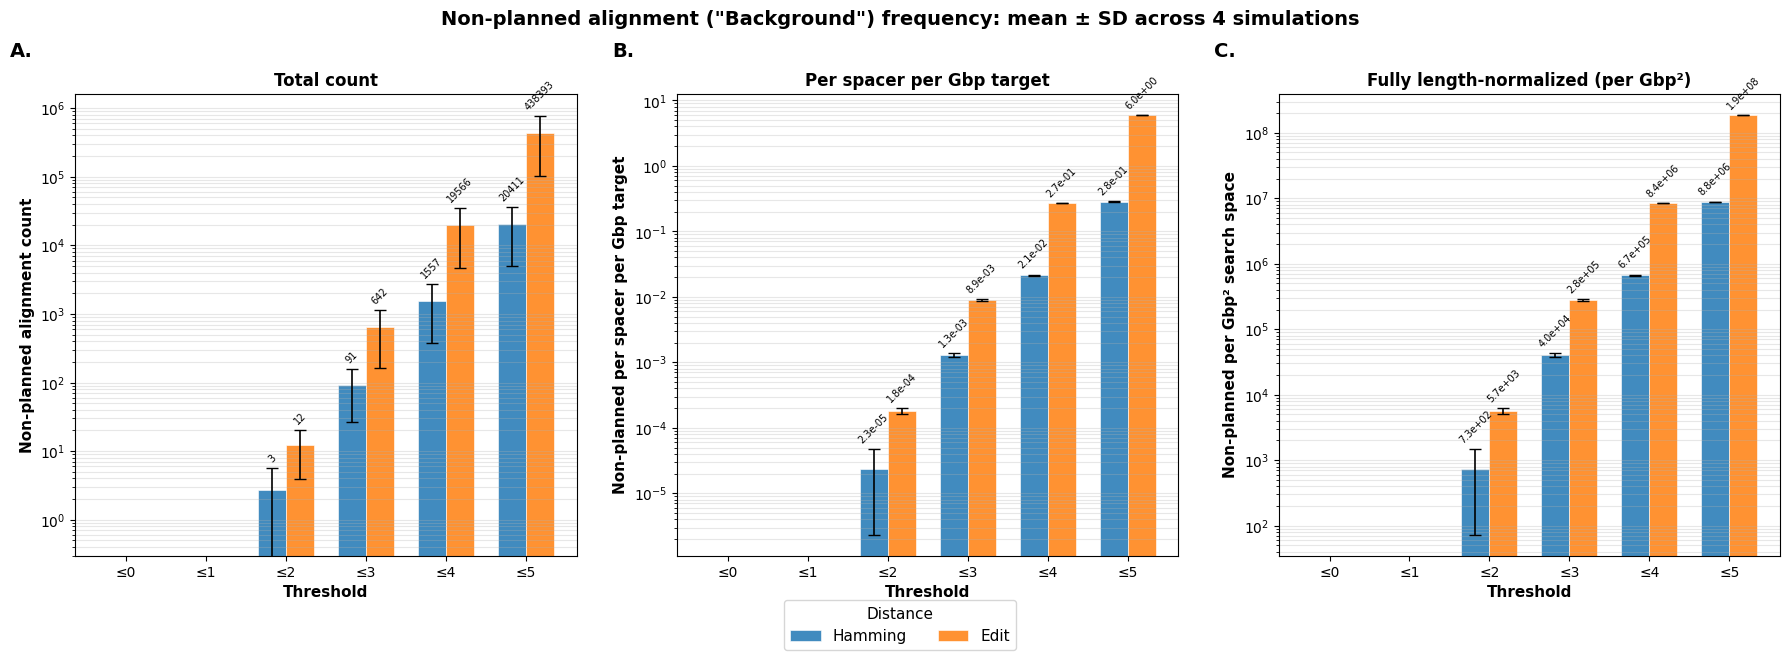

BACKGROUND NORMALIZATION SUMMARY (n=4 simulations)

--- Threshold ≤3 ---
  Total Count:
    Hamming: 9.12e+01 ± 6.45e+01
    Edit:    6.42e+02 ± 4.80e+02  (ratio: 7.04x)
  Per Spacer per Gbp Target:
    Hamming: 1.29e-03 ± 8.56e-05
    Edit:    8.89e-03 ± 2.81e-04  (ratio: 6.89x)
  Per Gbp² Search Space:
    Hamming: 4.03e+04 ± 2.67e+03
    Edit:    2.78e+05 ± 8.69e+03  (ratio: 6.89x)

--- Threshold ≤5 ---
  Total Count:
    Hamming: 2.04e+04 ± 1.54e+04
    Edit:    4.38e+05 ± 3.34e+05  (ratio: 21.48x)
  Per Spacer per Gbp Target:
    Hamming: 2.81e-01 ± 4.19e-03
    Edit:    6.02e+00 ± 3.67e-02  (ratio: 21.39x)
  Per Gbp² Search Space:
    Hamming: 8.79e+06 ± 1.28e+05
    Edit:    1.88e+08 ± 1.16e+06  (ratio: 21.39x)


In [ ]:
# Search space visualization: 3-panel grouped bar chart (absolute, per spacer per Gbp, per Gbp²)
# Mean ± SD across all simulations, at each threshold

bar_width = 0.35
x = np.arange(len(THRESHOLDS))

# Aggregate normalized metrics across simulations for each threshold
h_pspg_by_t = {t: [] for t in THRESHOLDS}  # per spacer per Gbp
e_pspg_by_t = {t: [] for t in THRESHOLDS}
h_pgbp2_by_t = {t: [] for t in THRESHOLDS}  # per Gbp²
e_pgbp2_by_t = {t: [] for t in THRESHOLDS}
h_count_by_t = {t: [] for t in THRESHOLDS}   # absolute counts (recomputed from search_df)
e_count_by_t = {t: [] for t in THRESHOLDS}

for row in search_space_data:
    t = row["threshold"]
    if row["metric"] == "Hamming":
        h_count_by_t[t].append(row["n_non_planned"])
        h_pspg_by_t[t].append(row["per_spacer_per_gbp"])
        h_pgbp2_by_t[t].append(row["per_gbp2"])
    else:
        e_count_by_t[t].append(row["n_non_planned"])
        e_pspg_by_t[t].append(row["per_spacer_per_gbp"])
        e_pgbp2_by_t[t].append(row["per_gbp2"])

# Compute means and stds for each panel
panel_data = []
for label, h_dict, e_dict in [
    ("Non-planned alignment count",          h_count_by_t, e_count_by_t),
    ("Non-planned per spacer per Gbp target", h_pspg_by_t,  e_pspg_by_t),
    ("Non-planned per Gbp\u00b2 search space",    h_pgbp2_by_t, e_pgbp2_by_t),
]:
    h_mean = np.array([np.mean(h_dict[t]) for t in THRESHOLDS])
    h_std  = np.array([np.std(h_dict[t]) for t in THRESHOLDS])
    e_mean = np.array([np.mean(e_dict[t]) for t in THRESHOLDS])
    e_std  = np.array([np.std(e_dict[t]) for t in THRESHOLDS])
    panel_data.append((label, h_mean, h_std, e_mean, e_std))

panel_titles = [
    "Total count",
    "Per spacer per Gbp target",
    "Fully length-normalized (per Gbp\u00b2)",
]

n_sims_ss = len(stats_lookup)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for idx, (ax, (ylabel, h_mean, h_std, e_mean, e_std)) in enumerate(zip(axes, panel_data)):
    # Plot actual means; zeros will have no visible bar on log scale
    h_plot = h_mean.copy()
    e_plot = e_mean.copy()

    # Clip lower error bars so they don't extend below the bar base
    h_err_lo = np.array([max(1e-30, min(h_std[i], h_plot[i] * 0.9)) if h_plot[i] > 0 else 0 for i in range(len(THRESHOLDS))])
    e_err_lo = np.array([max(1e-30, min(e_std[i], e_plot[i] * 0.9)) if e_plot[i] > 0 else 0 for i in range(len(THRESHOLDS))])
    h_err_hi = np.where(h_mean > 0, h_std, 0)
    e_err_hi = np.where(e_mean > 0, e_std, 0)

    ax.bar(x - bar_width/2, h_plot, bar_width, yerr=[h_err_lo, h_err_hi],
           label='Hamming', color='#1f77b4', alpha=0.85,
           edgecolor='white', linewidth=0.5, capsize=4, error_kw={'linewidth': 1.2})
    ax.bar(x + bar_width/2, e_plot, bar_width, yerr=[e_err_lo, e_err_hi],
           label='Edit', color='#ff7f0e', alpha=0.85,
           edgecolor='white', linewidth=0.5, capsize=4, error_kw={'linewidth': 1.2})

    # Annotate bars with mean values
    for i in range(len(THRESHOLDS)):
        if idx == 0:
            lh = f"{h_mean[i]:.0f}" if h_mean[i] >= 1 else f"{h_mean[i]:.1f}"
            le = f"{e_mean[i]:.0f}" if e_mean[i] >= 1 else f"{e_mean[i]:.1f}"
        else:
            lh = f"{h_mean[i]:.1e}" if h_mean[i] > 0 else "0"
            le = f"{e_mean[i]:.1e}" if e_mean[i] > 0 else "0"
        # For zero-mean bars, place label just above the axis bottom
        h_y = (h_plot[i] + h_std[i]) * 1.15 if h_mean[i] > 0 else None
        e_y = (e_plot[i] + e_std[i]) * 1.15 if e_mean[i] > 0 else None
        if h_y is not None:
            ax.text(x[i] - bar_width/2, h_y, lh, ha='center', va='bottom', fontsize=7, rotation=45)
        if e_y is not None:
            ax.text(x[i] + bar_width/2, e_y, le, ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_xlabel('Threshold', fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=11)
    ax.set_title(panel_titles[idx], fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([f'\u2264{t}' for t in THRESHOLDS])
    ax.set_yscale('log')
    if idx == 0:
        ax.set_ylim(bottom=0.3)
    ax.grid(True, alpha=0.3, axis='y', which='both')
    ax.text(-0.13, 1.08, f"{'ABC'[idx]}.", transform=ax.transAxes, fontsize=14, fontweight='bold')

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.06),
           ncol=2, frameon=True, fontsize=11, title='Distance', title_fontsize=11)

plt.suptitle(f'Non-planned alignment ("Background") frequency: mean \u00b1 SD across {n_sims_ss} simulations',
             fontsize=14, fontweight='bold', y=1.02)
# plt.tight_layout()

# Export SVG for manuscript
Path("draft/main/main_figures").mkdir(parents=True, exist_ok=True)
plt.savefig('draft/main/main_figures/Figure1_main_search_space_background_normalization.svg', bbox_inches='tight')
plt.savefig('draft/main/main_figures/Figure1_main_search_space_background_normalization.png', bbox_inches='tight', dpi=500)
plt.show()

# Save normalized metrics table (all thresholds)
search_df = pl.DataFrame(search_space_data)
Path("draft/supp/supp_tables").mkdir(parents=True, exist_ok=True)
search_df.write_csv('draft/supp/supp_tables/search_space_normalized_metrics.csv')

# Print summary at threshold ≤5 (same as before, for reference)
print(f"BACKGROUND NORMALIZATION SUMMARY (n={n_sims_ss} simulations)")
for t_show in [3, 5]:
    print(f"\n--- Threshold \u2264{t_show} ---")
    for col, title in [("n_non_planned", "Total Count"),
                        ("per_spacer_per_gbp", "Per Spacer per Gbp Target"),
                        ("per_gbp2", "Per Gbp\u00b2 Search Space")]:
        h_vals = search_df.filter((pl.col("metric") == "Hamming") & (pl.col("threshold") == t_show))[col].to_numpy()
        e_vals = search_df.filter((pl.col("metric") == "Edit") & (pl.col("threshold") == t_show))[col].to_numpy()
        h_m = h_vals.mean()
        e_m = e_vals.mean()
        ratio_str = f"{e_m / h_m:.2f}x" if h_m > 0 else "n/a"
        print(f"  {title}:")
        print(f"    Hamming: {h_m:.2e} \u00b1 {h_vals.std():.2e}")
        print(f"    Edit:    {e_m:.2e} \u00b1 {e_vals.std():.2e}  (ratio: {ratio_str})")

## Interpretation of Normalized Metrics

The normalized metrics are **INDEPENDENT** of how many planned insertions we made in the simulation.

**Best metric depends on the question:**
- **Per spacer per Gbp target**: For a given spacer, how many background hits do I expect when searching against 1 Gbp of target? Directly predictive for new experiments where query count and target size are known.
- **Per Gbp² search space**: How many background hits per unit of total search space (query bp × target bp)? This is the most general constant -- it accounts for varying spacer length distributions. Use this when comparing across datasets with different spacer length profiles.

**NOTE**: These metrics assume that spacers and contigs simulated are fairly "true to life" in terms of sequence complexity and repetitiveness. Moreover, the "n per x" normalization assumes xs and ns are populations allowing for scaling/sampling that support extrapolations. 

In our case:
- Most spacer lengths are in a fairly narrow range (20-40 bp) with a normal/close-to-normal distribution
- Contig lengths are more variable - we matched the distribution to real HQ IMG/VR4 data
- For researchers working on more localized datasets (e.g., single genome, small set of related genomes, or metagenome from the same source), sequence complexity and repetitiveness may differ significantly, affecting non-planned match rates

**That said**, these metrics should still be informative in a **comparative manner** (i.e., Hamming vs Edit distance and to what degree), as they use the same underlying data.

In [16]:
# Export threshold=3 subset to supplementary tables (data already computed in cell 11)

search_df_t3 = search_df#.filter(pl.col("threshold") == 3)

Path("draft/supp/supp_tables").mkdir(parents=True, exist_ok=True)
search_df_t3.write_csv("draft/supp/supp_tables/supp_table_S7_search_space_normalized.tsv",separator='\t')

print(search_df_t3)

shape: (48, 13)
┌────────────────────┬───────────┬─────────┬───────────┬───────────┬────────────┬──────────────┬───────────────┬────────────────┬───────────────┬──────────────────┬────────────────────┬───────────────┐
│ simulation         ┆ threshold ┆ metric  ┆ n_spacers ┆ n_contigs ┆ spacer_bp  ┆ contig_bp    ┆ count_product ┆ length_product ┆ n_non_planned ┆ non_planned_rate ┆ per_spacer_per_gbp ┆ per_gbp2      │
│ ---                ┆ ---       ┆ ---     ┆ ---       ┆ ---       ┆ ---        ┆ ---          ┆ ---           ┆ ---            ┆ ---           ┆ ---              ┆ ---                ┆ ---           │
│ str                ┆ i64       ┆ str     ┆ i64       ┆ i64       ┆ f64        ┆ f64          ┆ i64           ┆ f64            ┆ i64           ┆ f64              ┆ f64                ┆ f64           │
╞════════════════════╪═══════════╪═════════╪═══════════╪═══════════╪════════════╪══════════════╪═══════════════╪════════════════╪═══════════════╪══════════════════╪════════════

## Semi-Synthetic Dataset Analysis

The semi-synthetic dataset uses **real CRISPR spacers** from IMG/VR4 searched against **real viral contigs**. This provides:

- **Realistic base composition** (not uniform random)
- **Real sequence complexity** (repeats, low-complexity regions, etc.)
- **No planned insertions** - all matches are non-planned/chance matches
- **Large-scale testing** (~3.8M spacers × 421K contigs)

This is the closest approximation to real-world non-planned match rates.

**IMPORTANT**: For this dataset, we could only run **non-exhaustive gapless tools** (Hamming distance only). The exhaustive edit distance tool (sassy) is too compute-intensive for this large search space.

Key questions:
- Do non-planned frequencies differ from pure simulations?

- How do the normalized metrics compare?- Can we predict non-planned match counts for similar real-world datasets?

In [13]:
# Analyze semi-synthetic dataset(s) - HAMMING ONLY
if len(semisynthetic_sims) == 0:
    print("No semi-synthetic simulations found!")
else:
    semisynthetic_results = {}
    
    print(f"Processing {len(semisynthetic_sims)} semi-synthetic dataset(s)...\n")
    print("NOTE: Only analyzing Hamming distance (gapless tools).")
    print("      Edit distance tools (sassy) are too compute-intensive for this dataset.\n")
    
    for sim_dir in semisynthetic_sims:
        print(f"Processing {sim_dir.name}...")
        try:
            results = analyze_simulation_multi_metric(
                sim_dir,
                metrics=["hamming"],  # ONLY Hamming for semi-synthetic
                force_regenerate=False
            )
            semisynthetic_results[sim_dir.name] = results
            print(f"  ✓ Complete\n")
        except Exception as e:
            print(f"  ✗ ERROR: {e}\n")
            continue

        print(f"Successfully analyzed {len(semisynthetic_results)} semi-synthetic dataset(s)")

Processing 1 semi-synthetic dataset(s)...

NOTE: Only analyzing Hamming distance (gapless tools).
      Edit distance tools (sassy) are too compute-intensive for this dataset.

Processing ns_3826979_nc_421431_real_baseline...
✓ Multi-metric file exists: multi_metric_distances.parquet
  ✓ Complete

Successfully analyzed 1 semi-synthetic dataset(s)


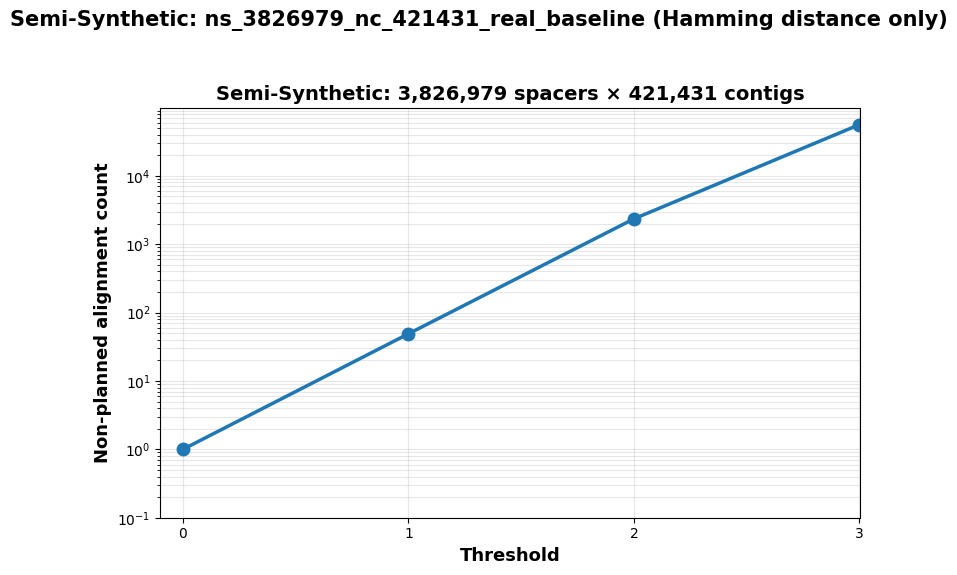

SEMI-SYNTHETIC DATASET STATISTICS (Hamming only)

ns_3826979_nc_421431_real_baseline:
Search space: 3,826,979 spacers x 421,431 contigs
  Spacer bp: 129,494,053   Contig bp: 21,470,981,225
  Length product: 2.78e+18 bp^2

Threshold    Non-planned Count 
≤0           1                 
≤1           49                
≤2           2,354             
≤3           56,273            
≤4           72,132            
≤5           113,314           

COMPARISON: Semi-Synthetic vs Simulated (n=4) -- Absolute Count
Threshold      Semi-syn      Sim avg       Sim SD      Ratio
≤0                    1          0.0          0.0       n/a
≤1                   49          0.0          0.0       n/a
≤2                2,354          2.8          2.9    856.00x
≤3               56,273         91.2         64.5    616.69x
≤4               72,132      1,556.8      1,178.6     46.33x
≤5              113,314     20,410.8     15,390.6      5.55x

COMPARISON: Semi-Synthetic vs Simulated -- Per Spacer per Gbp T

In [17]:
# Plot semi-synthetic results (HAMMING ONLY)
if len(semisynthetic_results) > 0:
    for sim_name, results in semisynthetic_results.items():
        # Parse simulation info
        parts = sim_name.split('_')
        n_spacers = int(parts[1])
        n_contigs = int(parts[3])

        # Compute FASTA stats for this semi-synthetic dataset
        ss_spacers_file = Path(f"results/simulated/{sim_name}/simulated_data/simulated_spacers.fa")
        ss_contig_file = Path(f"results/simulated/{sim_name}/simulated_data/simulated_contigs.fa")
        ss_spacer_stats = get_seq_stats_pl(ss_spacers_file)
        ss_contig_stats = get_seq_stats_pl(ss_contig_file)
        ss_spacer_bp = float(ss_spacer_stats["sum_length"].item())
        ss_contig_bp = float(ss_contig_stats["sum_length"].item())
        ss_n_spacers = int(ss_spacer_stats["n_seqs"].item())
        ss_n_contigs = int(ss_contig_stats["n_seqs"].item())
        ss_length_product = ss_spacer_bp * ss_contig_bp

        # Extract metrics
        hamming_counts = [results["hamming"][t]["n_non_planned"] for t in THRESHOLDS]

        # Compute normalized metrics for the semi-synthetic dataset
        ss_per_spacer_per_gbp = []
        ss_per_gbp2 = []
        for t in THRESHOLDS:
            c = hamming_counts[t]
            ss_per_spacer_per_gbp.append(c / (ss_n_spacers * ss_contig_bp / 1e9) if ss_contig_bp > 0 else 0)
            ss_per_gbp2.append(c / (ss_length_product / 1e18) if ss_length_product > 0 else 0)

        # Thresholds to display (hide >3.5)
        plot_thresholds = [t for t in THRESHOLDS if t <= 3.5]

        fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

        # Plot: Absolute counts (only up to 3.5)
        counts_plot = [max(val, 0.1) for val in hamming_counts]
        counts_plot_visible = [counts_plot[i] for i, t in enumerate(THRESHOLDS) if t <= 3.5]
        ax1.plot(plot_thresholds, counts_plot_visible, 'o-', label='Hamming (≤N)',
                 color='#1f77b4', linewidth=2.5, markersize=9)
        ax1.set_xlabel('Threshold', fontweight='bold', fontsize=13)
        ax1.set_ylabel('Non-planned alignment count', fontweight='bold', fontsize=13)
        ax1.set_title(f'Semi-Synthetic: {n_spacers:,} spacers × {n_contigs:,} contigs',
                      fontweight='bold', fontsize=14)
        ax1.set_xticks(plot_thresholds)
        ax1.set_xticklabels([str(t) for t in plot_thresholds])
        ax1.set_xlim(-0.1, max(plot_thresholds) if plot_thresholds else 3.5)
        ax1.set_yscale('log')
        ax1.set_ylim(bottom=0.1)
        ax1.grid(True, alpha=0.3, which='both')

        plt.suptitle(f'Semi-Synthetic: {sim_name} (Hamming distance only)',
                     fontsize=15, fontweight='bold', y=0.95)
        plt.tight_layout(rect=[0, 0, 1, 0.91])

        # Export SVG for supplementary
        Path("draft/supp/figures").mkdir(parents=True, exist_ok=True)
        fig.savefig(f'draft/supp/figures/{sim_name}_hamming_background.svg', bbox_inches='tight')
        plt.show()

        # Save table for supplementary (include normalized metrics)
        table_rows = []
        for i, t in enumerate(THRESHOLDS):
            table_rows.append({
                "threshold": t,
                "n_non_planned": hamming_counts[i],
                "per_spacer_per_gbp": ss_per_spacer_per_gbp[i],
                "per_gbp2": ss_per_gbp2[i],
            })
        Path("draft/supp/supp_tables/").mkdir(parents=True, exist_ok=True)
        pl.DataFrame(table_rows).write_csv(f'draft/supp/supp_tables/supp_table_S8_semi_synthetic_rates_hamming_background.tsv', separator='\t')

        # Print detailed statistics
        print("SEMI-SYNTHETIC DATASET STATISTICS (Hamming only)")
        print(f"\n{sim_name}:")
        print(f"Search space: {ss_n_spacers:,} spacers x {ss_n_contigs:,} contigs")
        print(f"  Spacer bp: {ss_spacer_bp:,.0f}   Contig bp: {ss_contig_bp:,.0f}")
        print(f"  Length product: {ss_length_product:.2e} bp^2")

        print(f"\n{'Threshold':<12} {'Non-planned Count':<18}")
        for t in THRESHOLDS:
            hamming = results["hamming"][t]
            print(f"≤{t:<11} {hamming['n_non_planned']:<18,}")

        # Compute simulated averages for normalized metrics (Hamming only)
        sim_pspg_mean = {t: np.mean(h_pspg_by_t[t]) for t in THRESHOLDS}
        sim_pspg_std  = {t: np.std(h_pspg_by_t[t]) for t in THRESHOLDS}
        sim_pgbp2_mean = {t: np.mean(h_pgbp2_by_t[t]) for t in THRESHOLDS}
        sim_pgbp2_std  = {t: np.std(h_pgbp2_by_t[t]) for t in THRESHOLDS}

        # Helper for ratio formatting when denominator may be zero
        def _ratio_str(num, denom):
            if denom > 0:
                return f"{num / denom:>9.2f}x"
            elif num > 0:
                return "      n/a"  # semi-syn > 0, simulated = 0
            else:
                return "      n/a"  # both zero

        # Comparison table: absolute count
        print("\nCOMPARISON: Semi-Synthetic vs Simulated (n={}) -- Absolute Count".format(len(all_results)))
        print(f"{'Threshold':<10} {'Semi-syn':>12} {'Sim avg':>12} {'Sim SD':>12} {'Ratio':>10}")
        for t in THRESHOLDS:
            ss_c = hamming_counts[t]
            sim_avg = h_count_mean[t]
            sim_sd = h_count_std[t]
            print(f"≤{t:<9} {ss_c:>12,} {sim_avg:>12,.1f} {sim_sd:>12,.1f} {_ratio_str(ss_c, sim_avg)}")

        # Comparison table: per spacer per Gbp target
        print("\nCOMPARISON: Semi-Synthetic vs Simulated -- Per Spacer per Gbp Target")
        print(f"{'Threshold':<10} {'Semi-syn':>14} {'Sim avg':>14} {'Sim SD':>14} {'Ratio':>10}")
        for t in THRESHOLDS:
            ss_v = ss_per_spacer_per_gbp[t]
            sim_v = sim_pspg_mean[t]
            sim_sd = sim_pspg_std[t]
            print(f"≤{t:<9} {ss_v:>14.4e} {sim_v:>14.4e} {sim_sd:>14.4e} {_ratio_str(ss_v, sim_v)}")

        # Comparison table: per Gbp² search space
        print("\nCOMPARISON: Semi-Synthetic vs Simulated -- Per Gbp² Search Space")
        print(f"{'Threshold':<10} {'Semi-syn':>14} {'Sim avg':>14} {'Sim SD':>14} {'Ratio':>10}")
        for t in THRESHOLDS:
            ss_v = ss_per_gbp2[t]
            sim_v = sim_pgbp2_mean[t]
            sim_sd = sim_pgbp2_std[t]
            print(f"≤{t:<9} {ss_v:>14.4e} {sim_v:>14.4e} {sim_sd:>14.4e} {_ratio_str(ss_v, sim_v)}")

else:
    print("No semi-synthetic results to plot")

## Summary
   - Edit distance consistently produces more background (non-planned) matches than Hamming (fold-change varies by threshold).
   - Both scale with threshold.
   - **Absolute counts**: The raw observation; dependent on dataset size.
   - **Per spacer per Gbp target**: Expected background hits per query spacer when searching against 1 Gbp of target. Directly predictive for new experiments.
   - **Per Gbp² search space**: Fully length-normalized rate accounting for query and target sizes. Best for cross-dataset comparison.
   - Normalized metrics remain relatively stable across simulations, at least within the same order of magnitude per metric per threshold.

## Semi-Synthetic vs Purely Simulated Datasets
   - Larger dataset (~3.8M spacers × 421K contigs)
   - Real base composition and complexity (IMG/VR4 data)
   - **Higher non-planned match rates**

### Notes:
   - Currently, no simulation has indel mutations. We added this functionality for future sake. 
   - We could only test hamming<=3 for the semi-synthetic dataset as it was too large for the exhaustive and edit-based tools. The values >3 should not be taken seriously.